# 08 — Distribution-shift stress tests

Is Bc's cold-solute advantage robust to *which* solutes get held out? Does
imposing Van't Hoff help more when the shift includes temperature extrapolation?


## 1. Goal

Notebook 07's cold-solute bootstrap gave a statistically significant Bc win,
but that was measured over one fixed partition of the solutes. The bootstrap
tells us about variability of examples inside that partition — it does not
tell us whether Bc would still win under a different choice of held-out solutes.

Two stress tests:

1. **Repeated cold-solute holdouts.** Generate several independent partitions
   and check whether Bc's advantage persists across them.
2. **Joint chemistry + temperature shift.** Hold out entire solutes AND
   evaluate on the upper-temperature region of their pairs. If Bc benefits
   scale with the amount of temperature-extrapolation content in the OOD shift,
   this is the split where the largest benefit should show up.

Only A and Bc are compared here. B and D are not repeated because notebook 07
established the mechanism (B's slope head is starved of gradient signal); the
scientific comparison is A (direct) vs Bc (conditioned Van't Hoff).


## 2. Repeated cold-solute holdouts

Generate 5 independent solute-level 80/10/10 partitions using different
split_seeds. For each partition, train A and Bc with 3 model_seeds and record
matched RMSE.

Each holdout gets its own b_scale computed from that partition's training
rows only — no leakage.


In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "scripts"))

from train import RES, train_one, SPLIT_NAMES, load_features, load_split, save_preds, metrics_row  # noqa: E402
from prepare_b_scale import per_pair_slopes  # noqa: E402
from models import T_REF  # noqa: E402

X_desc, T_arr, y, pair_id = load_features()
n = len(y)
print(f"rows: {n:,}   unique pairs: {len(np.unique(pair_id)):,}")

# Rebuild solute_id and solvent_id the same way 03_make_splits did.
DATA = ROOT / "data" / "BigSolDBv2.0.csv"
df = pd.read_csv(DATA).dropna(subset=["LogS(mol/L)"]).reset_index(drop=True)
assert len(df) == n, f"row count mismatch: {len(df)} vs features {n}"

solute_id  = pd.factorize(df["SMILES_Solute"].astype(str))[0]
solvent_id = pd.factorize(df["SMILES_Solvent"].astype(str))[0]

n_solutes  = int(solute_id.max()) + 1
n_solvents = int(solvent_id.max()) + 1
n_pairs    = len(np.unique(pair_id))
print(f"solutes = {n_solutes:,}   solvents = {n_solvents:,}")


rows: 100,983   unique pairs: 10,855


solutes = 1,445   solvents = 70


In [2]:
# Group-holdout helper (mirrors what 03_make_splits.ipynb did for cold-*).
def group_split(group_ids, n_groups, seed, frac_train=0.80, frac_val=0.10):
    rng = np.random.default_rng(seed)
    order = rng.permutation(n_groups)
    n_tr = int(round(frac_train * n_groups))
    n_va = int(round(frac_val   * n_groups))
    tr_g = set(order[:n_tr].tolist())
    va_g = set(order[n_tr : n_tr + n_va].tolist())
    te_g = set(order[n_tr + n_va :].tolist())
    tr = np.array([g in tr_g for g in group_ids])
    va = np.array([g in va_g for g in group_ids])
    te = np.array([g in te_g for g in group_ids])
    return np.where(tr)[0], np.where(va)[0], np.where(te)[0], (len(tr_g), len(va_g), len(te_g))


# Compute split-specific b_scale from training rows only.
def compute_b_scale(train_idx):
    slopes, _, _ = per_pair_slopes(T_arr, y, pair_id, train_idx)
    return float(np.median(np.abs(slopes))), int(len(slopes))


In [3]:
COLDSOL_SPLIT_SEEDS = [11, 22, 33, 44, 55]
MODEL_SEEDS         = [42, 123, 456]

OUT_CSV = RES / "metrics_repeated_coldsol.csv"

def append_row(csv_path, row):
    df_row = pd.DataFrame([row])
    if csv_path.exists():
        old = pd.read_csv(csv_path)
        pd.concat([old, df_row], ignore_index=True).to_csv(csv_path, index=False)
    else:
        df_row.to_csv(csv_path, index=False)


def load_done(csv_path):
    if not csv_path.exists():
        return set()
    d = pd.read_csv(csv_path)
    return {(str(r.model), int(r.split_seed), int(r.model_seed)) for r in d.itertuples()}


done = load_done(OUT_CSV)
t0 = time.time()

for split_seed in COLDSOL_SPLIT_SEEDS:
    tr_idx, va_idx, te_idx, group_counts = group_split(solute_id, n_solutes, seed=split_seed)
    b_scale, n_used = compute_b_scale(tr_idx)
    print(f"\n--- coldsol split_seed={split_seed}  "
          f"solutes tr/va/te={group_counts}  rows tr/va/te={len(tr_idx)}/{len(va_idx)}/{len(te_idx)}  "
          f"b_scale={b_scale:.2f} K  (from {n_used} pairs)")
    for kind in ["A", "Bc"]:
        for model_seed in MODEL_SEEDS:
            if (kind, split_seed, model_seed) in done:
                print(f"  [cached] {kind} seed {model_seed}")
                continue
            b = b_scale if kind == "Bc" else None
            metrics, elapsed, _ = train_one(
                kind, f"coldsol_ss{split_seed}", model_seed,
                device="cpu", b_scale=b, verbose=False,
                split_indices=(tr_idx, va_idx, te_idx),
            )
            row = {
                "model": kind, "split_seed": split_seed, "model_seed": model_seed,
                "n_solutes_test": group_counts[2],
                "train_n": len(tr_idx), "val_n": len(va_idx), "test_n": len(te_idx),
                "b_scale": b_scale if kind == "Bc" else None,
                "train_rmse": metrics["train"]["rmse"],
                "val_rmse":   metrics["val"]["rmse"],
                "test_rmse":  metrics["test"]["rmse"],
                "test_r2":    metrics["test"]["r2"],
                "elapsed_s":  round(elapsed, 1),
            }
            append_row(OUT_CSV, row)
            print(f"  {kind:>2}  seed {model_seed}  test_rmse={metrics['test']['rmse']:.4f}  "
                  f"elapsed={elapsed:.1f}s")

print(f"\ncoldsol repeated sweep total: {(time.time() - t0)/60:.1f} min")



--- coldsol split_seed=11  solutes tr/va/te=(1156, 144, 145)  rows tr/va/te=82253/9251/9479  b_scale=1376.98 K  (from 8561 pairs)


   A  seed 42  test_rmse=0.8453  elapsed=17.8s


   A  seed 123  test_rmse=0.8625  elapsed=22.1s


   A  seed 456  test_rmse=0.8755  elapsed=25.1s


  Bc  seed 42  test_rmse=0.8911  elapsed=18.0s


...

   A  seed 123  test_rmse=0.8626  elapsed=17.5s


   A  seed 456  test_rmse=0.8723  elapsed=17.4s


  Bc  seed 42  test_rmse=0.8462  elapsed=15.2s


  Bc  seed 123  test_rmse=0.8802  elapsed=43.0s


  Bc  seed 456  test_rmse=0.8811  elapsed=29.1s

coldsol repeated sweep total: 15.6 min


In [4]:
r_cs = pd.read_csv(OUT_CSV)

# Per-holdout mean over model seeds
holdout_mean = (r_cs.groupby(["split_seed", "model"])["test_rmse"]
                   .mean().unstack("model").reindex(columns=["A", "Bc"]))
holdout_mean["Bc - A"] = holdout_mean["Bc"] - holdout_mean["A"]

print("Per-holdout mean test RMSE across 3 model seeds:")
print(holdout_mean.round(4).to_string())
print()
print(f"across-holdout mean delta (Bc - A):   {holdout_mean['Bc - A'].mean():+.4f}")
print(f"across-holdout std  delta:            {holdout_mean['Bc - A'].std():.4f}")
print(f"holdouts where Bc is better:          "
      f"{int((holdout_mean['Bc - A'] < 0).sum())} / {len(holdout_mean)}")


Per-holdout mean test RMSE across 3 model seeds:
model            A      Bc  Bc - A
split_seed                        
11          0.8611  0.8833  0.0222
22          0.9981  1.0101  0.0120
33          0.8280  0.8355  0.0074
44          0.9044  0.9023 -0.0021
55          0.8663  0.8692  0.0028

across-holdout mean delta (Bc - A):   +0.0085
across-holdout std  delta:            0.0093
holdouts where Bc is better:          1 / 5


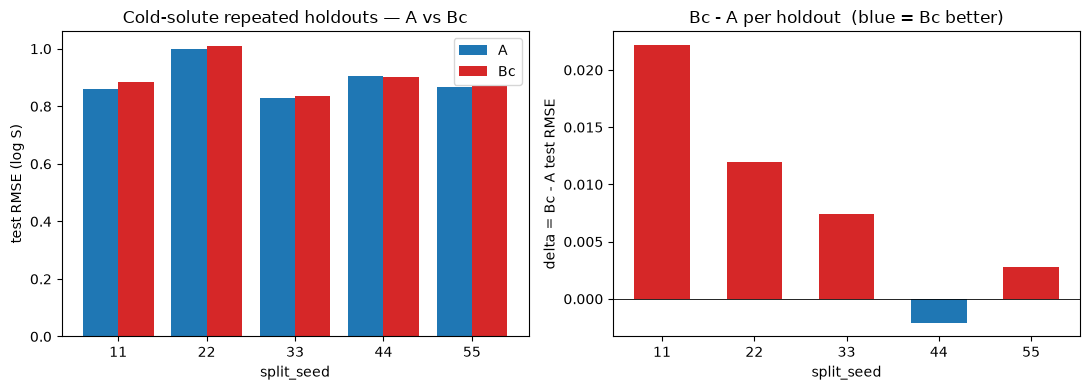

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
holdouts = holdout_mean.index.astype(str)

axes[0].bar(np.arange(len(holdouts)) - 0.2, holdout_mean["A"],  0.4,
            color="tab:blue", label="A")
axes[0].bar(np.arange(len(holdouts)) + 0.2, holdout_mean["Bc"], 0.4,
            color="tab:red",  label="Bc")
axes[0].set_xticks(np.arange(len(holdouts)))
axes[0].set_xticklabels(holdouts)
axes[0].set_xlabel("split_seed")
axes[0].set_ylabel("test RMSE (log S)")
axes[0].set_title("Cold-solute repeated holdouts — A vs Bc")
axes[0].legend()

deltas = holdout_mean["Bc - A"].values
colors = ["tab:blue" if d < 0 else "tab:red" for d in deltas]
axes[1].bar(np.arange(len(holdouts)), deltas, 0.6, color=colors)
axes[1].axhline(0, color="k", linewidth=0.6)
axes[1].set_xticks(np.arange(len(holdouts)))
axes[1].set_xticklabels(holdouts)
axes[1].set_xlabel("split_seed")
axes[1].set_ylabel("delta = Bc - A test RMSE")
axes[1].set_title("Bc - A per holdout  (blue = Bc better)")

plt.tight_layout()
plt.savefig(RES / "fig08_coldsol_repeated.png", dpi=140, bbox_inches="tight")
plt.show()


## 3. Repeated cold-pair holdouts (secondary)

Same pattern for pair-level holdouts. Fewer split_seeds since notebook 07 found
cold-pair had no significant Bc vs A signal even under bootstrap. Kept for
completeness.


In [6]:
COLDPAIR_SPLIT_SEEDS = [11, 22, 33]

OUT_CSV_PAIR = RES / "metrics_repeated_coldpair.csv"
done_p = load_done(OUT_CSV_PAIR)

t0 = time.time()
for split_seed in COLDPAIR_SPLIT_SEEDS:
    tr_idx, va_idx, te_idx, group_counts = group_split(pair_id, n_pairs, seed=split_seed)
    b_scale, n_used = compute_b_scale(tr_idx)
    print(f"\n--- coldpair split_seed={split_seed}  "
          f"pairs tr/va/te={group_counts}  rows tr/va/te={len(tr_idx)}/{len(va_idx)}/{len(te_idx)}  "
          f"b_scale={b_scale:.2f} K")
    for kind in ["A", "Bc"]:
        for model_seed in MODEL_SEEDS:
            if (kind, split_seed, model_seed) in done_p:
                print(f"  [cached] {kind} seed {model_seed}")
                continue
            b = b_scale if kind == "Bc" else None
            metrics, elapsed, _ = train_one(
                kind, f"coldpair_ss{split_seed}", model_seed,
                device="cpu", b_scale=b, verbose=False,
                split_indices=(tr_idx, va_idx, te_idx),
            )
            row = {
                "model": kind, "split_seed": split_seed, "model_seed": model_seed,
                "n_pairs_test": group_counts[2],
                "train_n": len(tr_idx), "val_n": len(va_idx), "test_n": len(te_idx),
                "b_scale": b_scale if kind == "Bc" else None,
                "train_rmse": metrics["train"]["rmse"],
                "val_rmse":   metrics["val"]["rmse"],
                "test_rmse":  metrics["test"]["rmse"],
                "test_r2":    metrics["test"]["r2"],
                "elapsed_s":  round(elapsed, 1),
            }
            append_row(OUT_CSV_PAIR, row)
            print(f"  {kind:>2}  seed {model_seed}  test_rmse={metrics['test']['rmse']:.4f}  "
                  f"elapsed={elapsed:.1f}s")

print(f"\ncoldpair repeated sweep total: {(time.time() - t0)/60:.1f} min")

r_cp = pd.read_csv(OUT_CSV_PAIR)
holdout_mean_p = (r_cp.groupby(["split_seed", "model"])["test_rmse"]
                     .mean().unstack("model").reindex(columns=["A", "Bc"]))
holdout_mean_p["Bc - A"] = holdout_mean_p["Bc"] - holdout_mean_p["A"]
print("\nPer-holdout mean test RMSE (cold-pair):")
print(holdout_mean_p.round(4).to_string())
print(f"across-holdout mean delta:  {holdout_mean_p['Bc - A'].mean():+.4f}")
print(f"holdouts where Bc better:   {int((holdout_mean_p['Bc - A'] < 0).sum())} / {len(holdout_mean_p)}")



--- coldpair split_seed=11  pairs tr/va/te=(8684, 1086, 1085)  rows tr/va/te=80925/10033/10025  b_scale=1378.68 K


   A  seed 42  test_rmse=0.5063  elapsed=41.6s


   A  seed 123  test_rmse=0.5155  elapsed=37.5s


   A  seed 456  test_rmse=0.4945  elapsed=68.3s


  Bc  seed 42  test_rmse=0.5025  elapsed=32.3s


...

   A  seed 123  test_rmse=0.5022  elapsed=59.3s


   A  seed 456  test_rmse=0.5060  elapsed=53.3s


  Bc  seed 42  test_rmse=0.5003  elapsed=56.2s


  Bc  seed 123  test_rmse=0.5021  elapsed=50.8s


  Bc  seed 456  test_rmse=0.5113  elapsed=75.1s

coldpair repeated sweep total: 16.9 min

Per-holdout mean test RMSE (cold-pair):
model            A      Bc  Bc - A
split_seed                        
11          0.5054  0.5027 -0.0027
22          0.5370  0.5461  0.0091
33          0.5145  0.5046 -0.0099
across-holdout mean delta:  -0.0012
holdouts where Bc better:   2 / 3


## 4. Joint shift: cold-solute + T-extrapolation

Construction:

1. Solute-level 80/10/10 split (train / val / test solutes) with a fixed seed
   so the split is reproducible.
2. Removing test solutes from training is guaranteed by construction — the
   solute never appears in the train or val portion.
3. For each pair whose solute is in the test set, require at least 3 rows and
   ≥20 K temperature range.
4. Within each eligible test pair, the test rows are those with
   $T > T_\text{min} + 0.75 (T_\text{max} - T_\text{min})$ — the upper 25 %
   of the pair's temperature range.
5. Non-test-region rows of test solutes are simply discarded (they cannot go
   to train without leaking chemistry, and putting them in val would leak
   T-adjacent chemistry into the early-stopping signal). Val comes from the
   val-solute rows only.

Report the size of every set explicitly.


In [7]:
JOINT_SPLIT_SEED = 42

tr_idx, va_idx_all, te_solute_rows, gc = group_split(solute_id, n_solutes, seed=JOINT_SPLIT_SEED)

print(f"solute partition  train/val/test = {gc}")
print(f"rows in solute train / val / test-solutes = "
      f"{len(tr_idx):,} / {len(va_idx_all):,} / {len(te_solute_rows):,}")

# For each test-solute pair, filter to eligible pairs and take the upper-T rows.
te_rows_selected = []
te_pair_meta = []
for pid in np.unique(pair_id[te_solute_rows]):
    rows_pid = np.where(pair_id == pid)[0]
    # sanity: all rows of a test-solute pair should live in te_solute_rows.
    assert set(rows_pid).issubset(set(te_solute_rows.tolist())), \
        f"leakage: pair {pid} spans train/val/test-solute sets"
    T_p = T_arr[rows_pid]
    if len(T_p) < 3:
        continue
    T_min, T_max = float(T_p.min()), float(T_p.max())
    if (T_max - T_min) < 20.0:
        continue
    T_bound = T_min + 0.75 * (T_max - T_min)
    upper = rows_pid[T_p > T_bound]
    if len(upper) == 0:
        continue
    te_rows_selected.append(upper)
    te_pair_meta.append({"pair_id": int(pid), "n_pair_rows": len(rows_pid),
                         "T_min": T_min, "T_max": T_max, "T_bound": T_bound,
                         "n_upper_rows": len(upper)})

te_idx_joint = np.sort(np.concatenate(te_rows_selected)) if te_rows_selected else np.array([], dtype=np.int64)
joint_meta = pd.DataFrame(te_pair_meta)

print()
print(f"eligible test pairs (n_rows>=3 AND dT>=20 K): {len(joint_meta)}")
print(f"test rows (upper 25% of each eligible pair's T range): {len(te_idx_joint):,}")
print(f"held-out test solutes:                                 {gc[2]}")
print()
print("test pair T-range summary:")
print(joint_meta[["n_pair_rows", "T_min", "T_max", "n_upper_rows"]].describe(percentiles=[.25, .5, .75]).round(2).to_string())


solute partition  train/val/test = (1156, 144, 145)
rows in solute train / val / test-solutes = 81,040 / 8,806 / 11,137



eligible test pairs (n_rows>=3 AND dT>=20 K): 1106
test rows (upper 25% of each eligible pair's T range): 2,820
held-out test solutes:                                 145

test pair T-range summary:
       n_pair_rows    T_min    T_max  n_upper_rows
count      1106.00  1106.00  1106.00       1106.00
mean          9.97   283.97   325.05          2.55
std           3.94     8.77    11.11          1.08
min           4.00   253.15   303.15          1.00
25%           8.00   278.15   318.15          2.00
50%           9.00   283.15   323.15          2.00
75%          10.00   288.15   328.15          3.00
max          50.00   333.15   383.35         10.00


In [8]:
# b_scale from training rows only — same rule as everywhere else.
b_scale_joint, n_pairs_used_j = compute_b_scale(tr_idx)
print(f"joint-split b_scale = {b_scale_joint:.2f} K  (from {n_pairs_used_j} pairs)")

OUT_CSV_JOINT = RES / "metrics_coldsol_textrap.csv"
done_j = load_done(OUT_CSV_JOINT)

t0 = time.time()
for kind in ["A", "Bc"]:
    for model_seed in MODEL_SEEDS:
        if (kind, JOINT_SPLIT_SEED, model_seed) in done_j:
            print(f"[cached] {kind} seed {model_seed}")
            continue
        b = b_scale_joint if kind == "Bc" else None
        metrics, elapsed, preds = train_one(
            kind, "coldsol_textrap", model_seed,
            device="cpu", b_scale=b, verbose=False,
            split_indices=(tr_idx, va_idx_all, te_idx_joint),
        )
        row = {
            "model": kind, "split_seed": JOINT_SPLIT_SEED, "model_seed": model_seed,
            "n_solutes_test": gc[2],
            "train_n": len(tr_idx), "val_n": len(va_idx_all), "test_n": len(te_idx_joint),
            "b_scale": b_scale_joint if kind == "Bc" else None,
            "train_rmse": metrics["train"]["rmse"],
            "val_rmse":   metrics["val"]["rmse"],
            "test_rmse":  metrics["test"]["rmse"],
            "test_r2":    metrics["test"]["r2"],
            "elapsed_s":  round(elapsed, 1),
        }
        append_row(OUT_CSV_JOINT, row)
        # Save prediction file for the bootstrap section.
        preds_dir = RES / "preds_coldsol_textrap"
        save_preds(preds, preds_dir)
        print(f"  {kind:>2}  seed {model_seed}  test_rmse={metrics['test']['rmse']:.4f}  "
              f"elapsed={elapsed:.1f}s")

print(f"\njoint split sweep total: {(time.time() - t0)/60:.1f} min")

r_j = pd.read_csv(OUT_CSV_JOINT)
joint_mean = r_j.groupby("model")["test_rmse"].agg(["mean", "std"])
joint_mean["n_seeds"] = r_j.groupby("model")["test_rmse"].count()
print()
print("Joint split (coldsol_textrap) — A vs Bc, mean +- std over 3 model seeds:")
print(joint_mean.round(4).to_string())
print(f"delta (Bc - A) mean: {joint_mean.loc['Bc','mean'] - joint_mean.loc['A','mean']:+.4f}")


joint-split b_scale = 1383.65 K  (from 8437 pairs)


   A  seed 42  test_rmse=0.9263  elapsed=29.0s


   A  seed 123  test_rmse=0.9248  elapsed=39.5s


   A  seed 456  test_rmse=0.9621  elapsed=24.1s


  Bc  seed 42  test_rmse=0.9349  elapsed=40.7s


  Bc  seed 123  test_rmse=0.9381  elapsed=53.2s


  Bc  seed 456  test_rmse=0.9489  elapsed=39.1s

joint split sweep total: 3.9 min

Joint split (coldsol_textrap) — A vs Bc, mean +- std over 3 model seeds:
         mean     std  n_seeds
model                         
A      0.9377  0.0211        3
Bc     0.9406  0.0073        3
delta (Bc - A) mean: +0.0029


## 5. Generalization matrix

Two axes: (unseen chemistry, unseen temperature). Fill each cell with A vs Bc
mean test RMSE. Values from notebook 06 are re-used where available; the
bottom-right cell is new here.


In [9]:
# Fetch A/Bc means from the multiseed benchmark table (notebook 06).
mstage = pd.read_csv(RES / "metrics_descriptor_multiseed.csv")
def mean_pair(split_name):
    a  = mstage.query("model=='A'  and split==@split_name")["test_rmse"].mean()
    bc = mstage.query("model=='Bc' and split==@split_name")["test_rmse"].mean()
    return float(a), float(bc)

a_rand,  bc_rand  = mean_pair("random")
a_text,  bc_text  = mean_pair("textrap")
a_cold,  bc_cold  = mean_pair("coldsol")

a_j  = float(r_j.query("model=='A'" ).test_rmse.mean())
bc_j = float(r_j.query("model=='Bc'").test_rmse.mean())

matrix = pd.DataFrame(
    [
        {"row":"Known / covered T", "chemistry":"Known (random)",
         "A": a_rand, "Bc": bc_rand, "Bc - A": bc_rand - a_rand},
        {"row":"Known / covered T", "chemistry":"Unseen (cold-solute)",
         "A": a_cold, "Bc": bc_cold, "Bc - A": bc_cold - a_cold},
        {"row":"Extrapolated T",    "chemistry":"Known (T-extrap)",
         "A": a_text, "Bc": bc_text, "Bc - A": bc_text - a_text},
        {"row":"Extrapolated T",    "chemistry":"Unseen (coldsol-T-extrap)",
         "A": a_j,    "Bc": bc_j,    "Bc - A": bc_j - a_j},
    ]
)
matrix = matrix.round(4)
print("Generalization matrix — test RMSE, mean across 3 model seeds:")
print(matrix.to_string(index=False))


Generalization matrix — test RMSE, mean across 3 model seeds:
              row                 chemistry      A     Bc  Bc - A
Known / covered T            Known (random) 0.2014 0.2043  0.0029
Known / covered T      Unseen (cold-solute) 0.8935 0.8883 -0.0052
   Extrapolated T          Known (T-extrap) 0.2435 0.2241 -0.0194
   Extrapolated T Unseen (coldsol-T-extrap) 0.9377 0.9406  0.0029


## 6. Uncertainty analysis

Repeated cold-solute: variance across held-out chemistry sets (standard deviation
of per-holdout mean delta).

Joint split: paired cluster bootstrap over pair_id, ensemble predictions across
3 model seeds. Only informative if the number of clusters (test pairs) is not
tiny.


In [10]:
def cluster_bootstrap_from_preds_dir(preds_dir, split_label, n_boot=2000, seed=0):
    files_A  = sorted(preds_dir.glob(f"preds_A_{split_label}_seed*.npz"))
    files_Bc = sorted(preds_dir.glob(f"preds_Bc_{split_label}_seed*.npz"))
    if not files_A or not files_Bc:
        return None
    # Ensemble-mean predictions across seeds, matched on test_idx.
    def load_stack(files):
        acc = None
        for f in files:
            d = np.load(f, allow_pickle=True)
            y_pred = d["y_pred"]
            if acc is None:
                idx = d["test_idx"]
                pid = d["pair_id"]
                y_true = d["y_true"]
                acc = np.zeros_like(y_pred, dtype=np.float64)
            acc += y_pred.astype(np.float64)
        return acc / len(files), idx, pid, y_true
    y_A,  idxA, pidA, ytrue  = load_stack(files_A)
    y_Bc, idxB, pidB, _      = load_stack(files_Bc)
    assert np.array_equal(idxA, idxB) and np.array_equal(pidA, pidB)
    df = pd.DataFrame({"pair_id": pidA, "y_true": ytrue, "y_A": y_A, "y_Bc": y_Bc})
    df["se_A"]  = (df["y_A"]  - df["y_true"]) ** 2
    df["se_Bc"] = (df["y_Bc"] - df["y_true"]) ** 2
    obs_diff = float(np.sqrt(df["se_Bc"].mean()) - np.sqrt(df["se_A"].mean()))

    rng = np.random.default_rng(seed)
    pair_list = df["pair_id"].unique()
    pair_to_rows = {p: g.index.values for p, g in df.groupby("pair_id")}
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        picked = rng.choice(pair_list, size=len(pair_list), replace=True)
        rows = np.concatenate([pair_to_rows[p] for p in picked])
        se_A_boot  = df["se_A"].values[rows]
        se_Bc_boot = df["se_Bc"].values[rows]
        diffs[i]   = np.sqrt(se_Bc_boot.mean()) - np.sqrt(se_A_boot.mean())
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    return {"obs_diff": obs_diff,
            "ci_lo": float(ci_lo), "ci_hi": float(ci_hi),
            "prob_Bc_better": float(np.mean(diffs < 0)),
            "n_pairs": int(len(pair_list)), "n_rows": int(len(df))}

boot_joint = cluster_bootstrap_from_preds_dir(RES / "preds_coldsol_textrap", "coldsol_textrap")
if boot_joint is not None:
    print("Joint split (coldsol_textrap) paired cluster bootstrap:")
    for k, v in boot_joint.items():
        if isinstance(v, float):
            print(f"  {k:>14}: {v:+.4f}")
        else:
            print(f"  {k:>14}: {v}")
else:
    print("bootstrap not available (missing pred files)")

# Repeated cold-sol summary (variance across holdouts, not across seeds)
per_holdout_delta = holdout_mean["Bc - A"]
print()
print("Repeated cold-solute variability:")
print(f"  n_holdouts:          {len(per_holdout_delta)}")
print(f"  mean(delta):         {per_holdout_delta.mean():+.4f}")
print(f"  std across holdouts: {per_holdout_delta.std():.4f}")
print(f"  min / max delta:     {per_holdout_delta.min():+.4f} / {per_holdout_delta.max():+.4f}")
print(f"  fraction Bc wins:    {(per_holdout_delta < 0).mean():.2f}")


Joint split (coldsol_textrap) paired cluster bootstrap:
        obs_diff: +0.0031
           ci_lo: -0.0102
           ci_hi: +0.0159
  prob_Bc_better: +0.3325
         n_pairs: 1106
          n_rows: 2820

Repeated cold-solute variability:
  n_holdouts:          5
  mean(delta):         +0.0085
  std across holdouts: 0.0093
  min / max delta:     -0.0021 / +0.0222
  fraction Bc wins:    0.20


## 7. Interpretation

Careful language. Read the results computed above and pick the appropriate
statement without overclaiming.


In [11]:
def _fmt_delta(x):
    return f"{x:+.4f}"

# Repeated cold-solute reading
cs_delta = holdout_mean["Bc - A"]
cs_mean  = float(cs_delta.mean())
cs_std   = float(cs_delta.std())
cs_frac  = float((cs_delta < 0).mean())
if cs_frac >= 0.8 and cs_mean < -cs_std:
    cs_verdict = "Bc wins consistently across chemistry partitions"
elif cs_frac <= 0.2 and cs_mean > cs_std:
    cs_verdict = "Bc loses consistently across chemistry partitions"
else:
    cs_verdict = "chemistry-only generalization remains unresolved / weak"

# Cold-pair
cp_delta = holdout_mean_p["Bc - A"]
cp_mean  = float(cp_delta.mean())
cp_std   = float(cp_delta.std())
cp_frac  = float((cp_delta < 0).mean())
if cp_frac >= 0.8 and cp_mean < -cp_std:
    cp_verdict = "Bc wins consistently on cold-pair"
elif cp_frac <= 0.2 and cp_mean > cp_std:
    cp_verdict = "Bc loses consistently on cold-pair"
else:
    cp_verdict = "cold-pair remains mixed"

# Joint split
if boot_joint is not None:
    if boot_joint["ci_hi"] < 0:
        joint_verdict = "Bc statistically better on joint chemistry + T shift"
    elif boot_joint["ci_lo"] > 0:
        joint_verdict = "Bc statistically worse on joint chemistry + T shift"
    else:
        joint_verdict = "joint chemistry + T shift: no significant difference"
else:
    joint_verdict = "joint split evaluation unavailable"

# Compare magnitude of Bc benefit between fixed cold-sol and joint (both hold out chemistry)
a_cold_mean = matrix.loc[matrix["chemistry"]=="Unseen (cold-solute)", "Bc - A"].values[0]
a_joint_mean = matrix.loc[matrix["chemistry"]=="Unseen (coldsol-T-extrap)", "Bc - A"].values[0]

conclusion = pd.DataFrame([
    {"question": "Is Bc's cold-solute win robust to which solutes are held out?",
     "result": f"{cs_frac:.0%} of {len(cs_delta)} holdouts show Bc<A, mean delta = {_fmt_delta(cs_mean)} +- {cs_std:.4f}. "
               f"Verdict: {cs_verdict}."},
    {"question": "Does Bc help on cold-pair when the held-out pairs vary?",
     "result": f"{cp_frac:.0%} of {len(cp_delta)} holdouts show Bc<A, mean delta = {_fmt_delta(cp_mean)} +- {cp_std:.4f}. "
               f"Verdict: {cp_verdict}."},
    {"question": "Does Bc help on joint chemistry + T shift?",
     "result": (f"delta = {_fmt_delta(boot_joint['obs_diff'])}, "
                f"95% CI [{_fmt_delta(boot_joint['ci_lo'])}, {_fmt_delta(boot_joint['ci_hi'])}]. "
                f"{joint_verdict}. n_pairs={boot_joint['n_pairs']}, n_rows={boot_joint['n_rows']}.") if boot_joint else "n/a"},
    {"question": "Does the Bc benefit scale with T-extrapolation content?",
     "result": (f"fixed cold-solute delta = {_fmt_delta(a_cold_mean)}; "
                f"joint (cold-solute + T-extrap) delta = {_fmt_delta(a_joint_mean)}. "
                f"{'larger' if a_joint_mean < a_cold_mean else 'not larger'} on the joint shift.")},
])
conclusion


,question,result
0,Is Bc's cold-solute win robust to which solute...,"20% of 5 holdouts show Bc<A, mean delta = +0.0..."
1,Does Bc help on cold-pair when the held-out pa...,"67% of 3 holdouts show Bc<A, mean delta = -0.0..."
2,Does Bc help on joint chemistry + T shift?,"delta = +0.0031, 95% CI [-0.0102, +0.0159]. jo..."
3,Does the Bc benefit scale with T-extrapolation...,fixed cold-solute delta = -0.0052; joint (cold...
